In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

### Preprocessed Daten laden

In [3]:
df = pd.read_csv(r'C:\Users\markd\.vscode\Fitness-exercise\data\processed\fitness_preprocessed.csv')

df.head()

,duration_min,pulse_bpm,max_pulse_bpm,calories,calories_imputed,duration_min_outlier,pulse_bpm_outlier,max_pulse_bpm_outlier,calories_outlier,calories_per_min
0,60,110,130,409.1,0,0,0,0,0,6.82
1,60,117,145,479.0,0,0,0,0,0,7.98
2,60,103,135,340.0,0,0,0,0,0,5.67
3,45,109,175,282.4,0,0,0,1,0,6.28
4,45,117,148,406.0,0,0,0,0,0,9.02


### Datenstruktur überprüfen

In [4]:
print("Datentypen:")
display(df.dtypes.to_frame(name="Datentyp"))

Datentypen:


,Datentyp
duration_min,int64
pulse_bpm,int64
max_pulse_bpm,int64
calories,float64
calories_imputed,int64
duration_min_outlier,int64
pulse_bpm_outlier,int64
max_pulse_bpm_outlier,int64
calories_outlier,int64
calories_per_min,float64


### Fehlende Werte überprüfen

In [5]:
print("Fehlende Werte:")
display(df.isna().sum().to_frame(name="Fehlende Werte"))

Fehlende Werte:


,Fehlende Werte
duration_min,0
pulse_bpm,0
max_pulse_bpm,0
calories,0
calories_imputed,0
duration_min_outlier,0
pulse_bpm_outlier,0
max_pulse_bpm_outlier,0
calories_outlier,0
calories_per_min,0


### Deskiptive Statistik

In [6]:
print("Deskripitive Statistik:")
display(df.describe().T)

Deskripitive Statistik:


,count,mean,std,min,25%,50%,75%,max
duration_min,162.0,64.197531,43.151882,15.00,45.0000,60.000,60.00,300.00
pulse_bpm,162.0,107.709877,14.711588,80.00,100.0000,105.500,111.00,159.00
max_pulse_bpm,162.0,134.265432,16.471618,100.00,124.0000,131.000,141.00,184.00
calories,162.0,377.593210,267.291955,50.30,255.0750,320.400,386.70,1860.40
calories_imputed,162.0,0.030864,0.173486,0.00,0.0000,0.000,0.00,1.00
duration_min_outlier,162.0,0.216049,0.412824,0.00,0.0000,0.000,0.00,1.00
pulse_bpm_outlier,162.0,0.111111,0.315244,0.00,0.0000,0.000,0.00,1.00
max_pulse_bpm_outlier,162.0,0.080247,0.272517,0.00,0.0000,0.000,0.00,1.00
calories_outlier,162.0,0.117284,0.322756,0.00,0.0000,0.000,0.00,1.00
calories_per_min,162.0,6.011481,1.603759,2.24,5.0025,5.875,6.67,11.47


### Feature: Herzfrequenzreserve

Die Herzfrequenzreserve beschreibt die Differenz zwischen den maximalen Puls und dem durchschnittlichen Puls während des Trainings

In [7]:
df["heart_rate_reserve"] = (df["max_pulse_bpm"] - df["pulse_bpm"])

display(df[["pulse_bpm", "max_pulse_bpm", "heart_rate_reserve"]].head())

,pulse_bpm,max_pulse_bpm,heart_rate_reserve
0,110,130,20
1,117,145,28
2,103,135,32
3,109,175,66
4,117,148,31


### Feature: Verhältnis von Puls zu Maximalpuls

Dieses Feature zeigt, wie stark die durchschnittliche Belastung im Verhältnis zum maximal gemessenen Puls war.

In [8]:
df["pulse_to_max_ratio"] = (df["pulse_bpm"] / df["max_pulse_bpm"]).round(3)

display(df[["pulse_bpm", "max_pulse_bpm", "pulse_to_max_ratio"]].head())

,pulse_bpm,max_pulse_bpm,pulse_to_max_ratio
0,110,130,0.846
1,117,145,0.807
2,103,135,0.763
3,109,175,0.623
4,117,148,0.791


### Feature: Trainigsintensität

Die Trainingsintensität wird anhand des Verhältnisses von durchschnittlichem Puls zu Maximalpuls eingeteilt.

In [9]:
intensity_bins = [0, 0.60, 0.75, 0.85, 1.00]
intensity_labels = ["Niedrig", "Moderat", "Hoch", "Sehr Hoch"]

df["intensity_category"] = pd.cut(df["pulse_to_max_ratio"], bins=intensity_bins, labels=intensity_labels, include_lowest=True)

display(df[["pulse_to_max_ratio", "intensity_category"]].head())

print(df["intensity_category"].value_counts(dropna=False))

,pulse_to_max_ratio,intensity_category
0,0.846,Hoch
1,0.807,Hoch
2,0.763,Hoch
3,0.623,Moderat
4,0.791,Hoch


intensity_category
Hoch         117
Moderat       26
Sehr Hoch     17
NaN            2
Niedrig        0
Name: count, dtype: int64


### Feature: Dauer

Die Dauer wird in leicht interpretierbare Gruppen überführt.


In [10]:
duration_bins = [0, 30, 60, 90, np.inf]
duration_labels = ["Kurz (<30min)", "Mittel (31-60min)", "Lang (61-90min)", "Sehr lang (>90min)"]

df["duration_category"] = pd.cut(df["duration_min"], bins=duration_bins, labels=duration_labels, include_lowest=True)

display(df[["duration_min", "duration_category"]].head())

print(df["duration_category"].value_counts(dropna=False))

,duration_min,duration_category
0,60,Mittel (31-60min)
1,60,Mittel (31-60min)
2,60,Mittel (31-60min)
3,45,Mittel (31-60min)
4,45,Mittel (31-60min)


duration_category
Mittel (31-60min)     107
Kurz (<30min)          28
Sehr lang (>90min)     16
Lang (61-90min)        11
Name: count, dtype: int64


### Feature: Kalorienverbrauch kategorisieren

In [11]:
calorie_bins = [0, 200, 400, 600, np.inf]
calorie_labels = ["Niedrig (<200kcal)", "Mittel (201-400kcal)", "Hoch (401-600kcal)", "Sehr Hoch (>600kcal)"]

df["calorie_category"] = pd.cut(df["calories"], bins=calorie_bins, labels=calorie_labels, include_lowest=True)

display(df[["calories", "calorie_category"]].head())

print(df["calorie_category"].value_counts(dropna=False))

,calories,calorie_category
0,409.1,Hoch (401-600kcal)
1,479.0,Hoch (401-600kcal)
2,340.0,Mittel (201-400kcal)
3,282.4,Mittel (201-400kcal)
4,406.0,Hoch (401-600kcal)


calorie_category
Mittel (201-400kcal)    107
Niedrig (<200kcal)       20
Hoch (401-600kcal)       18
Sehr Hoch (>600kcal)     17
Name: count, dtype: int64


### Feature: Kalorien pro Herzschlag

Dieses Feature setzt den Kalorienverbrauch ins Verhältnis zur ungefähren Anzahl an Herzschlägen während des Trainings.

In [12]:
df["estimated_total_beats"] = (df["pulse_bpm"] * df["duration_min"])

df["calories_per_beat"] = (df["calories"] / df["estimated_total_beats"]).round(5)

display(df[["duration_min", "pulse_bpm", "calories", "estimated_total_beats", "calories_per_beat"]].head())

,duration_min,pulse_bpm,calories,estimated_total_beats,calories_per_beat
0,60,110,409.1,6600,0.06198
1,60,117,479.0,7020,0.06823
2,60,103,340.0,6180,0.05502
3,45,109,282.4,4905,0.05757
4,45,117,406.0,5265,0.07711


### Feature: Trainingsbelastung

Das Feature kmobiniert Trainingsdauer und durchschnittlichen Puls als vereinfachtes Maß für die gesamte Trainingsbelastung.

In [13]:
df["training_load"] = (df["duration_min"] * df["pulse_bpm"])

display(df[["duration_min", "pulse_bpm", "training_load"]].head())

,duration_min,pulse_bpm,training_load
0,60,110,6600
1,60,117,7020
2,60,103,6180
3,45,109,4905
4,45,117,5265


### Feature: Trainingsbelastung kategorisieren

In [14]:
load_bins = [-np.inf,
             df["training_load"].quantile(0.25),
             df["training_load"].quantile(0.50),
             df["training_load"].quantile(0.75),
             np.inf]

load_labels = ["Niedrige Belastung", "Mittlere Belastung", "Hohe Belastung", "Sehr hohe Belastung"]

df["training_load_category"] = pd.cut(df["training_load"], bins=load_bins, labels=load_labels, include_lowest=True)

print(df["training_load_category"].value_counts())

training_load_category
Niedrige Belastung     42
Mittlere Belastung     42
Sehr hohe Belastung    41
Hohe Belastung         37
Name: count, dtype: int64


### Numerische Features standardisieren

In [17]:
features_to_scale = ["duration_min", "pulse_bpm", "max_pulse_bpm", "calories_per_min", "heart_rate_reserve", "pulse_to_max_ratio", "training_load", "calories_per_beat"]

scaler = StandardScaler()

scaled_features = scaler.fit_transform(df[features_to_scale])

scaled_df = pd.DataFrame(scaled_features, columns=[f"{col}_scaled" for col in features_to_scale], index=df.index)

df = pd.concat([df, scaled_df], axis=1)

display(df.head())

,duration_min,pulse_bpm,max_pulse_bpm,calories,calories_imputed,duration_min_outlier,pulse_bpm_outlier,max_pulse_bpm_outlier,calories_outlier,calories_per_min,...,training_load,training_load_category,duration_min_scaled,pulse_bpm_scaled,max_pulse_bpm_scaled,calories_per_min_scaled,heart_rate_reserve_scaled,pulse_to_max_ratio_scaled,training_load_scaled,calories_per_beat_scaled
0,60,110,130,409.1,0,0,0,0,0,6.82,...,6600,Hohe Belastung,-0.097575,0.156151,-0.259759,0.505703,-0.637773,0.569941,-0.046750,0.578743
1,60,117,145,479.0,0,0,0,0,0,7.98,...,7020,Sehr hohe Belastung,-0.097575,0.633441,0.653722,1.231246,0.140526,0.038837,0.045676,1.136382
2,60,103,135,340.0,0,0,0,0,0,5.67,...,6180,Hohe Belastung,-0.097575,-0.321140,0.044734,-0.213586,0.529676,-0.560358,-0.139176,-0.042243
3,45,109,175,282.4,0,0,0,1,0,6.28,...,4905,Mittlere Belastung,-0.446262,0.087966,2.480684,0.167950,3.837445,-2.466885,-0.419755,0.185274
4,45,117,148,406.0,0,0,0,0,0,9.02,...,5265,Mittlere Belastung,-0.446262,0.633441,0.836418,1.881734,0.432388,-0.179052,-0.340532,1.928674


### Engineering validieren

In [19]:
print("Datensatzgröße nach Engineering: ")
print(df.shape)

print("\nFehlende Werte nach Engineering: ")

display(df.isna().sum().sort_values(ascending=False).to_frame(name="Fehlende Werte"))

print("\nDatentypen nach Engineering: ")
display(df.dtypes.to_frame(name="Datentyp"))

Datensatzgröße nach Engineering: 
(162, 27)

Fehlende Werte nach Engineering: 


,Fehlende Werte
intensity_category,2
pulse_bpm,0
duration_min,0
calories,0
calories_imputed,0
duration_min_outlier,0
pulse_bpm_outlier,0
max_pulse_bpm_outlier,0
calories_outlier,0
calories_per_min,0



Datentypen nach Engineering: 


,Datentyp
duration_min,int64
pulse_bpm,int64
max_pulse_bpm,int64
calories,float64
calories_imputed,int64
duration_min_outlier,int64
pulse_bpm_outlier,int64
max_pulse_bpm_outlier,int64
calories_outlier,int64
calories_per_min,float64


### Korrelation der numerischen Features

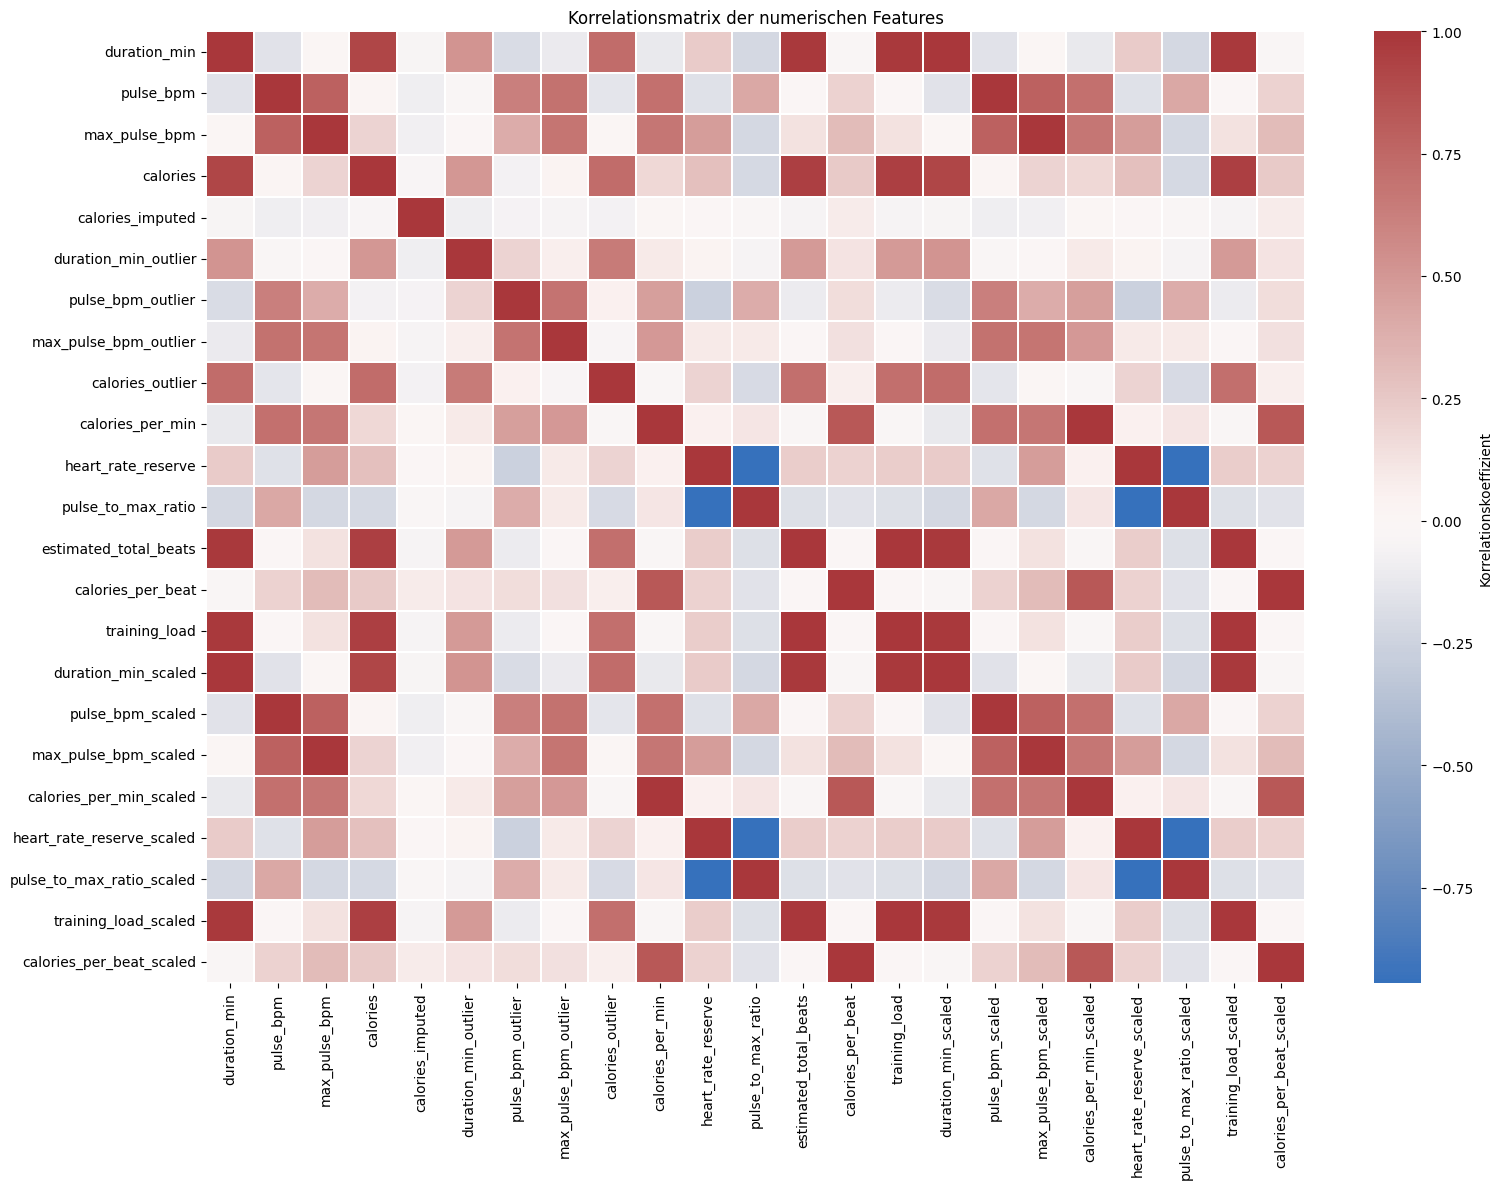

In [20]:
numeric_df = df.select_dtypes(include=[np.number])

correlation_matrix = numeric_df.corr()

plt.figure(figsize=(16, 12))

sns.heatmap(correlation_matrix, cmap="vlag", center=0, linewidths=0.3, cbar_kws={"label": "Korrelationskoeffizient"})

plt.title("Korrelationsmatrix der numerischen Features")
plt.tight_layout()
plt.show()


### Verteilung der Trainingsintensität

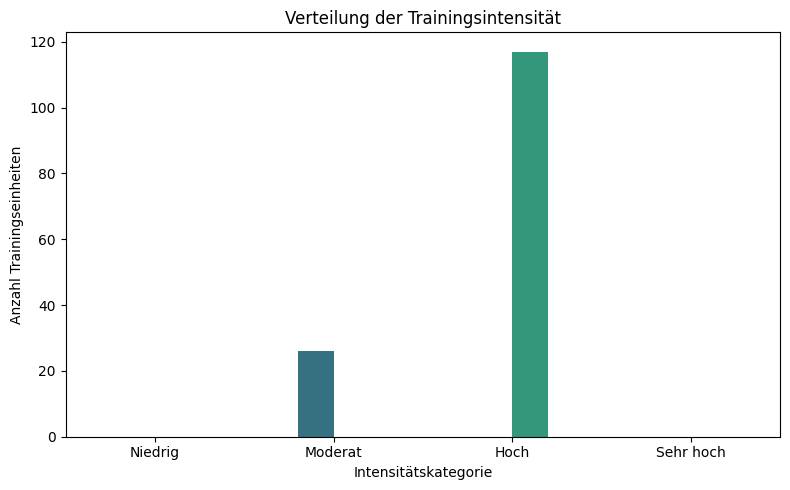

In [21]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="intensity_category",
    hue="intensity_category",
    palette="viridis",
    legend=False,
    order=["Niedrig", "Moderat", "Hoch", "Sehr hoch"]
)

plt.title("Verteilung der Trainingsintensität")
plt.xlabel("Intensitätskategorie")
plt.ylabel("Anzahl Trainingseinheiten")
plt.tight_layout()
plt.show()

### Trainingsbelastung nach Intesitätskategorie

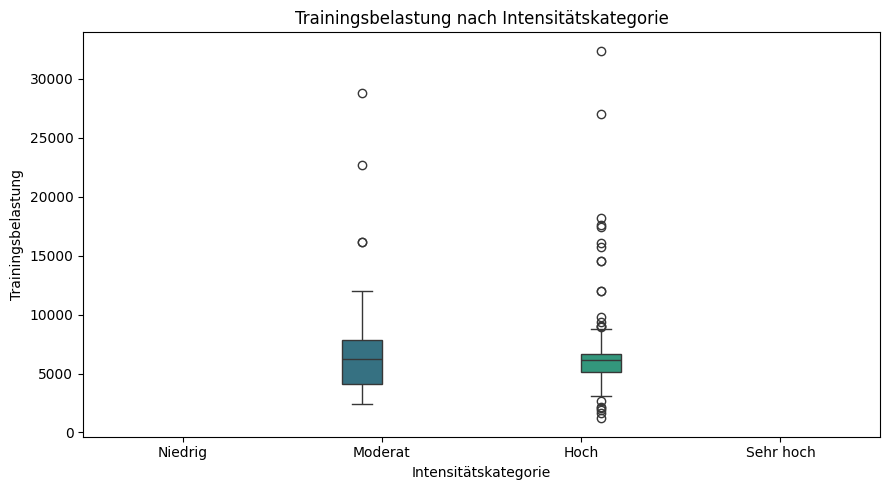

In [22]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x="intensity_category",
    y="training_load",
    hue="intensity_category",
    palette="viridis",
    legend=False,
    order=["Niedrig", "Moderat", "Hoch", "Sehr hoch"]
)

plt.title("Trainingsbelastung nach Intensitätskategorie")
plt.xlabel("Intensitätskategorie")
plt.ylabel("Trainingsbelastung")
plt.tight_layout()
plt.show()

### Feature Engineering Datensatz exportieren

In [23]:
feature_engineered_df = df.copy()

feature_engineered_df.to_csv(
    "fitness_feature_engineered.csv",
    index=False
)

print(
    "Feature-Engineering-Datensatz erfolgreich gespeichert: "
    "fitness_feature_engineered.csv"
)

Feature-Engineering-Datensatz erfolgreich gespeichert: fitness_feature_engineered.csv
